In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

DATA_DIR = Path("../data/processed")

print("EDA environment ready.")
print("Data directory:", DATA_DIR.resolve())

EDA environment ready.
Data directory: C:\Users\Siddh\Desktop\BidGuard-AI\data\processed


In [2]:
# Load all BidGuard AI datasets

tenders = pd.read_csv(DATA_DIR / "tenders.csv")
tender_requirements = pd.read_csv(DATA_DIR / "tender_requirements.csv")
bidder_tenders = pd.read_csv(DATA_DIR / "bidder_tenders.csv")
bidders = pd.read_csv(DATA_DIR / "bidders.csv")
documents = pd.read_csv(DATA_DIR / "documents.csv")
document_fields = pd.read_csv(DATA_DIR / "document_fields.csv")
document_pages = pd.read_csv(DATA_DIR / "document_pages.csv")
evidence = pd.read_csv(DATA_DIR / "evidence.csv")
requirement_evidence = pd.read_csv(DATA_DIR / "requirement_evidence.csv")
compliance_results = pd.read_csv(DATA_DIR / "compliance_results.csv")
risk_dataset = pd.read_csv(DATA_DIR / "risk_dataset.csv")

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [3]:
datasets = {
    "Tenders": tenders,
    "Tender Requirements": tender_requirements,
    "Bidder Tenders": bidder_tenders,
    "Bidders": bidders,
    "Documents": documents,
    "Document Fields": document_fields,
    "Document Pages": document_pages,
    "Evidence": evidence,
    "Requirement Evidence": requirement_evidence,
    "Compliance Results": compliance_results,
    "Risk Dataset": risk_dataset
}

overview = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()]
})

overview

,Dataset,Rows,Columns
0,Tenders,1200,18
1,Tender Requirements,31233,16
2,Bidder Tenders,4748,12
3,Bidders,2000,12
4,Documents,27367,15
5,Document Fields,223125,9
6,Document Pages,123027,7
7,Evidence,41845,9
8,Requirement Evidence,123703,13
9,Compliance Results,123703,13


In [4]:
# Overall missing-value count by dataset

for name, df in datasets.items():
    missing = df.isnull().sum().sum()
    print(f"{name:25} → {missing:,} missing values")

Tenders                   → 0 missing values
Tender Requirements       → 77,457 missing values
Bidder Tenders            → 0 missing values
Bidders                   → 0 missing values
Documents                 → 18,075 missing values
Document Fields           → 0 missing values
Document Pages            → 0 missing values
Evidence                  → 0 missing values
Requirement Evidence      → 60,564 missing values
Compliance Results        → 45,423 missing values
Risk Dataset              → 0 missing values


In [5]:
# Column-level missing-value analysis

for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]

    if len(missing) > 0:
        print(f"\n{'=' * 70}")
        print(name)
        print("=" * 70)

        result = pd.DataFrame({
            "Missing Count": missing,
            "Missing %": (missing / len(df) * 100).round(2)
        })

        print(result.to_string())


Tender Requirements
               Missing Count  Missing %
minimum_value          23112       74.0
maximum_value          31233      100.0
unit                   23112       74.0

Documents
             Missing Count  Missing %
expiry_date          18075      66.05

Requirement Evidence
               Missing Count  Missing %
document_id            15141      12.24
evidence_id            15141      12.24
page_number            15141      12.24
evidence_text          15141      12.24

Compliance Results
                      Missing Count  Missing %
evidence_document_id          15141      12.24
evidence_page                 15141      12.24
evidence_id                   15141      12.24


In [6]:
# Dataset-level missing-value summary

missing_summary = []

for name, df in datasets.items():
    total_cells = df.shape[0] * df.shape[1]
    missing_cells = df.isnull().sum().sum()

    missing_summary.append({
        "Dataset": name,
        "Missing Cells": missing_cells,
        "Missing %": round((missing_cells / total_cells) * 100, 2)
    })

missing_df = pd.DataFrame(missing_summary)

missing_df

,Dataset,Missing Cells,Missing %
0,Tenders,0,0.00
1,Tender Requirements,77457,15.50
2,Bidder Tenders,0,0.00
3,Bidders,0,0.00
4,Documents,18075,4.40
5,Document Fields,0,0.00
6,Document Pages,0,0.00
7,Evidence,0,0.00
8,Requirement Evidence,60564,3.77
9,Compliance Results,45423,2.82


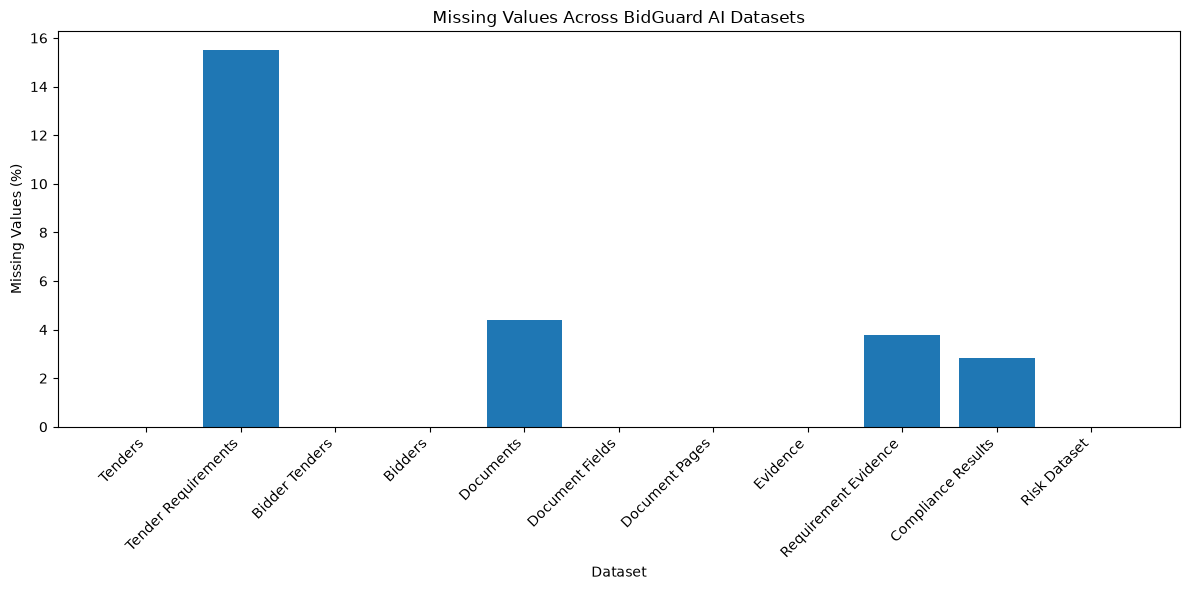

In [7]:
plt.figure(figsize=(12, 6))

plt.bar(
    missing_df["Dataset"],
    missing_df["Missing %"]
)

plt.ylabel("Missing Values (%)")
plt.xlabel("Dataset")
plt.title("Missing Values Across BidGuard AI Datasets")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [8]:
# Data type summary

for name, df in datasets.items():
    print(f"\n{'=' * 60}")
    print(name)
    print("=" * 60)
    print(df.dtypes.value_counts())


Tenders
str        13
int64       3
float64     1
bool        1
Name: count, dtype: int64

Tender Requirements
str        11
float64     2
bool        2
int64       1
Name: count, dtype: int64

Bidder Tenders
str        8
float64    2
int64      1
bool       1
Name: count, dtype: int64

Bidders
str      11
int64     1
Name: count, dtype: int64

Documents
str      11
bool      2
int64     2
Name: count, dtype: int64

Document Fields
str        6
float64    1
int64      1
bool       1
Name: count, dtype: int64

Document Pages
str        4
int64      1
bool       1
float64    1
Name: count, dtype: int64

Evidence
str        7
int64      1
float64    1
Name: count, dtype: int64

Requirement Evidence
str        9
float64    4
Name: count, dtype: int64

Compliance Results
str        10
float64     2
bool        1
Name: count, dtype: int64

Risk Dataset
int64      15
str         3
float64     3
Name: count, dtype: int64


In [9]:
# Column names of all datasets

for name, df in datasets.items():
    print(f"\n{name}")
    print("-" * len(name))
    print(df.columns.tolist())


Tenders
-------
['tender_id', 'tender_title', 'procuring_organization', 'department', 'procurement_category', 'tender_type', 'issue_date', 'submission_deadline', 'estimated_value', 'currency', 'location_state', 'location_city', 'minimum_eligibility_summary', 'number_of_requirements', 'mandatory_requirement_count', 'optional_requirement_count', 'difficulty_level', 'synthetic_flag']

Tender Requirements
-------------------
['requirement_id', 'tender_id', 'requirement_text', 'requirement_category', 'requirement_subcategory', 'metric', 'minimum_value', 'maximum_value', 'unit', 'mandatory', 'required_document_type', 'validity_required', 'verification_type', 'severity_if_failed', 'difficulty_level', 'linguistic_variant']

Bidder Tenders
--------------
['bidder_tender_id', 'tender_id', 'bidder_id', 'bid_submission_date', 'bid_status', 'participation_status', 'bid_amount', 'documents_submitted_count', 'submission_completeness', 'scenario', 'difficulty_level', 'synthetic_flag']

Bidders
------

In [11]:
# ============================================================
# Tender Requirements - Exact Column Inspection
# ============================================================

tr = datasets["Tender Requirements"]

print("=" * 70)
print("TENDER REQUIREMENTS - COLUMN INSPECTION")
print("=" * 70)

print("\nShape:", tr.shape)

print("\nColumns:")
for i, col in enumerate(tr.columns, 1):
    print(f"{i:2}. {col}")

print("\nData Types:")
print(tr.dtypes.to_string())

TENDER REQUIREMENTS - COLUMN INSPECTION

Shape: (31233, 16)

Columns:
 1. requirement_id
 2. tender_id
 3. requirement_text
 4. requirement_category
 5. requirement_subcategory
 6. metric
 7. minimum_value
 8. maximum_value
 9. unit
10. mandatory
11. required_document_type
12. validity_required
13. verification_type
14. severity_if_failed
15. difficulty_level
16. linguistic_variant

Data Types:
requirement_id                 str
tender_id                      str
requirement_text               str
requirement_category           str
requirement_subcategory        str
metric                         str
minimum_value              float64
maximum_value              float64
unit                           str
mandatory                     bool
required_document_type         str
validity_required             bool
verification_type              str
severity_if_failed             str
difficulty_level               str
linguistic_variant           int64


In [12]:
# ============================================================
# Requirement Category Analysis
# ============================================================

tr = datasets["Tender Requirements"]

print("=" * 70)
print("REQUIREMENT CATEGORY ANALYSIS")
print("=" * 70)

print("\nRequirement Categories:")
print(tr["requirement_category"].value_counts(dropna=False).to_string())

print("\nMandatory Requirements:")
print(tr["mandatory"].value_counts(dropna=False).to_string())

print("\nVerification Types:")
print(tr["verification_type"].value_counts(dropna=False).to_string())

print("\nSeverity if Failed:")
print(tr["severity_if_failed"].value_counts(dropna=False).to_string())

REQUIREMENT CATEGORY ANALYSIS

Requirement Categories:
requirement_category
NSIC                     2974
EPFO/ESIC                2959
Legal eligibility        2942
Local Content            2882
Turnover                 2866
Technical eligibility    2860
Tender-specific          2855
Udyam/MSME               2843
Startup India            2754
GST                      1200
PAN                      1200
Experience               1200
Financial                1200
OEM Authorization         498

Mandatory Requirements:
mandatory
True     20207
False    11026

Verification Types:
verification_type
DATE_CHECK         6333
SEMANTIC_MATCH     6321
THRESHOLD_CHECK    6299
FIELD_MATCH        6179
CROSS_DOCUMENT     6101

Severity if Failed:
severity_if_failed
MEDIUM      8768
LOW         8674
HIGH        8493
CRITICAL    5298


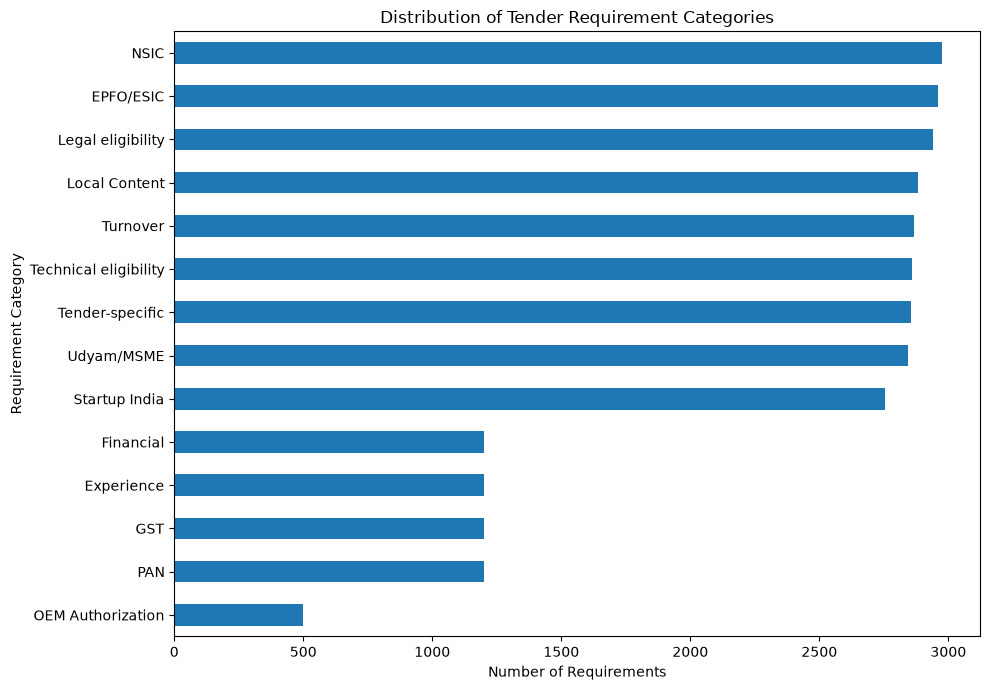

In [13]:
# ============================================================
# Requirement Category Distribution
# ============================================================

tr = datasets["Tender Requirements"]

category_counts = (
    tr["requirement_category"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))

category_counts.plot(kind="barh")

plt.title("Distribution of Tender Requirement Categories")
plt.xlabel("Number of Requirements")
plt.ylabel("Requirement Category")
plt.tight_layout()
plt.show()

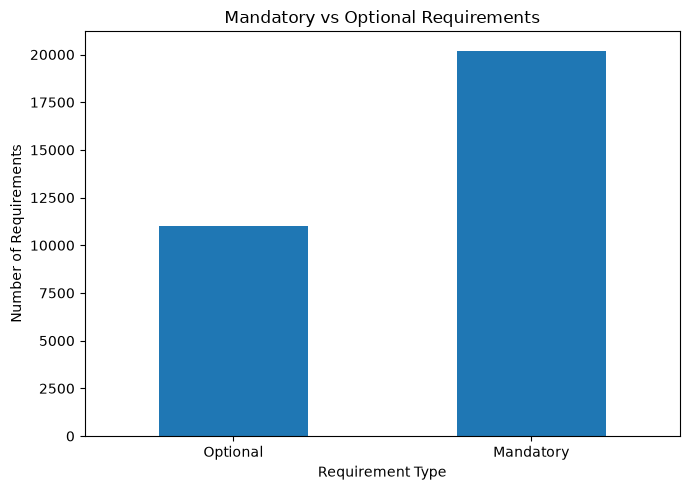

In [14]:
# ============================================================
# Mandatory vs Optional Requirements
# ============================================================

mandatory_counts = tr["mandatory"].value_counts()

labels = ["Optional", "Mandatory"]

plt.figure(figsize=(7, 5))

mandatory_counts.reindex([False, True]).plot(
    kind="bar"
)

plt.title("Mandatory vs Optional Requirements")
plt.xlabel("Requirement Type")
plt.ylabel("Number of Requirements")
plt.xticks(range(2), labels, rotation=0)
plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# Documents Dataset Analysis
# ============================================================

docs = datasets["Documents"]

print("=" * 70)
print("DOCUMENTS DATASET ANALYSIS")
print("=" * 70)

print("\nShape:", docs.shape)

print("\nDocument Types:")
print(docs["document_type"].value_counts(dropna=False).to_string())

print("\nDocument Status:")
print(docs["document_status"].value_counts(dropna=False).to_string())

print("\nMissing Values:")
print(docs.isnull().sum().sort_values(ascending=False).to_string())

DOCUMENTS DATASET ANALYSIS

Shape: (27367, 15)

Document Types:
document_type
GST Certificate                4675
PAN Document                   4663
Experience Certificate         4641
Financial/Turnover Document    4634
Supporting Document            4137
Udyam/MSME Certificate         3211
OEM Authorization              1406

Document Status:
document_status
VALID           22549
INCOMPLETE       2067
INCONSISTENT      966
INVALID           898
EXPIRED           887

Missing Values:
expiry_date                 18075
bidder_id                       0
document_id                     0
document_type                   0
document_name                   0
document_status                 0
tender_id                       0
issue_date                      0
company_name_on_document        0
document_quality                0
ocr_required                    0
page_count                      0
source_page                     0
difficulty_level                0
synthetic_flag                  0

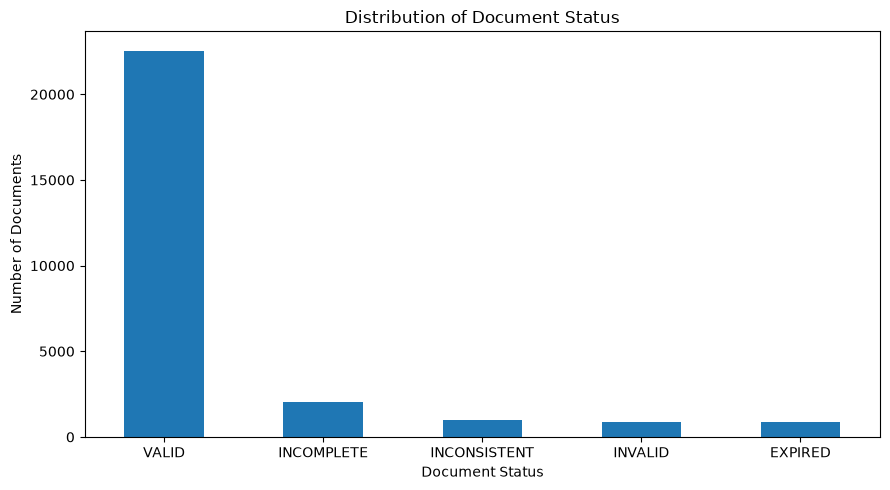

In [16]:
# ============================================================
# Document Status Distribution
# ============================================================

status_counts = docs["document_status"].value_counts()

plt.figure(figsize=(9, 5))
status_counts.plot(kind="bar")

plt.title("Distribution of Document Status")
plt.xlabel("Document Status")
plt.ylabel("Number of Documents")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

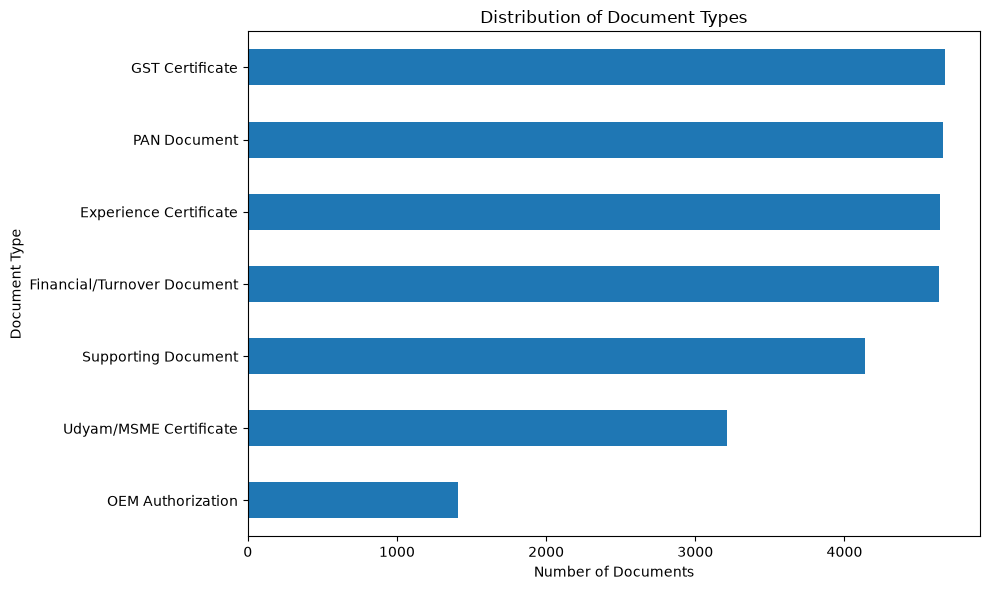

In [17]:
# ============================================================
# Document Type Distribution
# ============================================================

doc_type_counts = docs["document_type"].value_counts()

plt.figure(figsize=(10, 6))
doc_type_counts.sort_values().plot(kind="barh")

plt.title("Distribution of Document Types")
plt.xlabel("Number of Documents")
plt.ylabel("Document Type")
plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# EVIDENCE DATASET ANALYSIS
# ============================================================

print("=" * 70)
print("EVIDENCE DATASET ANALYSIS")
print("=" * 70)

print("\nShape:")
print(evidence.shape)

print("\nColumns:")
print(evidence.columns.tolist())

print("\nEvidence Types:")
print(evidence["evidence_type"].value_counts())

print("\nMissing Values:")
print(evidence.isnull().sum().sort_values(ascending=False))

EVIDENCE DATASET ANALYSIS

Shape:
(41845, 9)

Columns:
['evidence_id', 'document_id', 'tender_id', 'bidder_id', 'page_number', 'text_snippet', 'evidence_type', 'relevance_label', 'extraction_confidence']

Evidence Types:
evidence_type
ENTITY          12859
EVIDENCE        12771
NARRATIVE        8987
INTRODUCTION     4204
DECLARATION      2034
GENERAL           990
Name: count, dtype: int64

Missing Values:
evidence_id              0
document_id              0
tender_id                0
bidder_id                0
page_number              0
text_snippet             0
evidence_type            0
relevance_label          0
extraction_confidence    0
dtype: int64


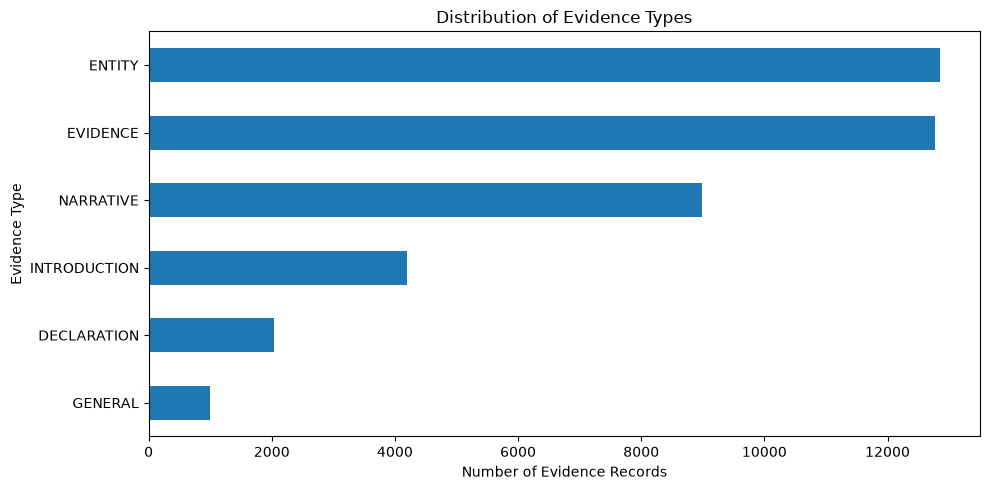

In [20]:
# ============================================================
# Evidence Type Distribution
# ============================================================

evidence_type_counts = evidence["evidence_type"].value_counts()

plt.figure(figsize=(10, 5))
evidence_type_counts.sort_values().plot(kind="barh")

plt.title("Distribution of Evidence Types")
plt.xlabel("Number of Evidence Records")
plt.ylabel("Evidence Type")
plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# REQUIREMENT EVIDENCE DATASET ANALYSIS
# ============================================================

print("=" * 70)
print("REQUIREMENT EVIDENCE DATASET ANALYSIS")
print("=" * 70)

print("\nShape:")
print(requirement_evidence.shape)

print("\nColumns:")
print(requirement_evidence.columns.tolist())

print("\nMissing Values:")
print(
    requirement_evidence.isnull()
    .sum()
    .sort_values(ascending=False)
)

print("\nData Types:")
print(requirement_evidence.dtypes)

REQUIREMENT EVIDENCE DATASET ANALYSIS

Shape:
(123703, 13)

Columns:
['requirement_evidence_id', 'tender_id', 'bidder_id', 'requirement_id', 'document_id', 'evidence_id', 'page_number', 'requirement_text', 'evidence_text', 'semantic_relevance', 'evidence_sufficiency', 'evidence_confidence', 'final_evidence_label']

Missing Values:
document_id                15141
page_number                15141
evidence_text              15141
evidence_id                15141
requirement_evidence_id        0
requirement_id                 0
bidder_id                      0
tender_id                      0
requirement_text               0
semantic_relevance             0
evidence_sufficiency           0
evidence_confidence            0
final_evidence_label           0
dtype: int64

Data Types:
requirement_evidence_id        str
tender_id                      str
bidder_id                      str
requirement_id                 str
document_id                    str
evidence_id                    str
pa

In [22]:
# ============================================================
# FINAL EVIDENCE LABEL ANALYSIS
# ============================================================

print("=" * 70)
print("FINAL EVIDENCE LABEL ANALYSIS")
print("=" * 70)

print("\nFinal Evidence Labels:")
print(requirement_evidence["final_evidence_label"].value_counts())

print("\nSemantic Relevance Summary:")
print(requirement_evidence["semantic_relevance"].describe().round(3))

print("\nEvidence Sufficiency Summary:")
print(requirement_evidence["evidence_sufficiency"].describe().round(3))

print("\nEvidence Confidence Summary:")
print(requirement_evidence["evidence_confidence"].describe().round(3))

FINAL EVIDENCE LABEL ANALYSIS

Final Evidence Labels:
final_evidence_label
SUPPORTS              74864
DOES_NOT_SUPPORT      17829
PARTIALLY_SUPPORTS    15869
NO_EVIDENCE           15141
Name: count, dtype: int64

Semantic Relevance Summary:
count    123703.000
mean          0.658
std           0.354
min           0.030
25%           0.450
50%           0.920
75%           0.920
max           0.920
Name: semantic_relevance, dtype: float64

Evidence Sufficiency Summary:
count    123703.000
mean          0.623
std           0.393
min           0.000
25%           0.250
50%           0.920
75%           0.920
max           0.920
Name: evidence_sufficiency, dtype: float64

Evidence Confidence Summary:
count    123703.000
mean          0.753
std           0.280
min           0.030
25%           0.758
50%           0.836
75%           0.911
max           0.990
Name: evidence_confidence, dtype: float64


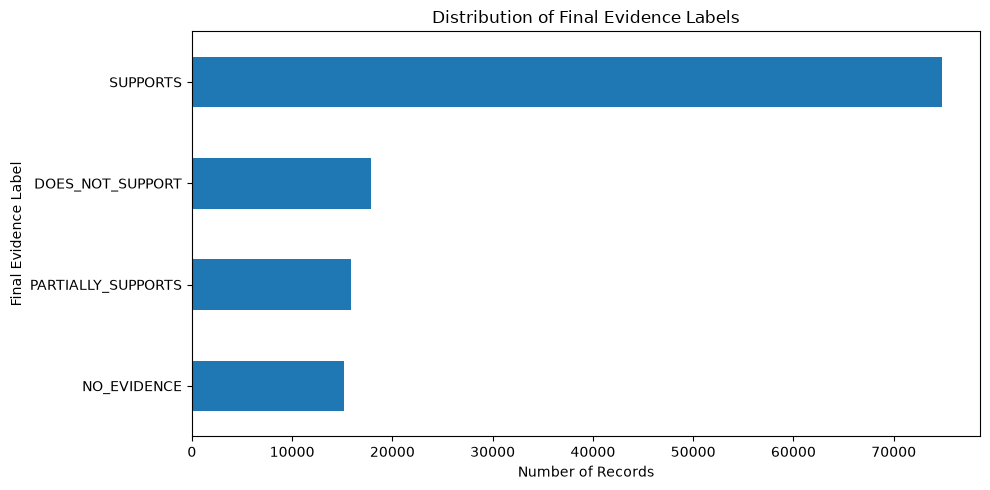

In [23]:
# ============================================================
# Final Evidence Label Distribution
# ============================================================

label_counts = requirement_evidence["final_evidence_label"].value_counts()

plt.figure(figsize=(10, 5))
label_counts.sort_values().plot(kind="barh")

plt.title("Distribution of Final Evidence Labels")
plt.xlabel("Number of Records")
plt.ylabel("Final Evidence Label")
plt.tight_layout()
plt.show()

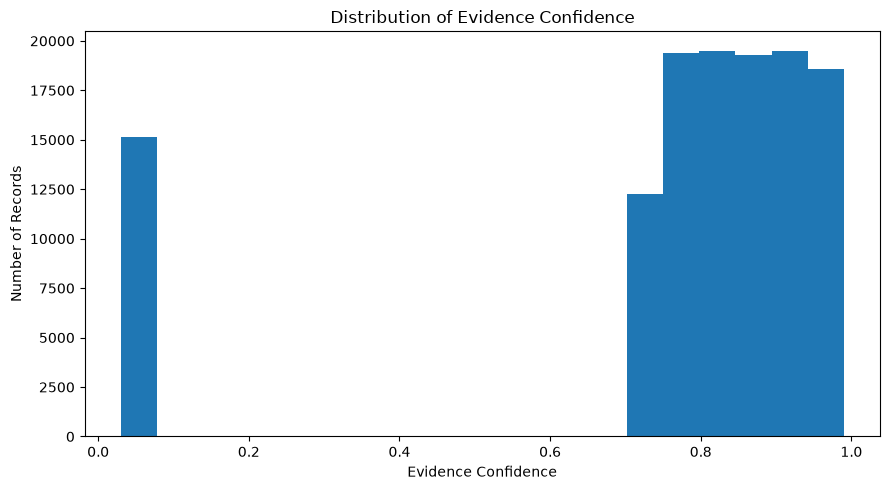

In [24]:
# ============================================================
# Evidence Confidence Distribution
# ============================================================

plt.figure(figsize=(9, 5))
requirement_evidence["evidence_confidence"].plot(
    kind="hist",
    bins=20
)

plt.title("Distribution of Evidence Confidence")
plt.xlabel("Evidence Confidence")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# COMPLIANCE RESULTS DATASET ANALYSIS
# ============================================================

print("=" * 70)
print("COMPLIANCE RESULTS DATASET ANALYSIS")
print("=" * 70)

print("\nShape:")
print(compliance_results.shape)

print("\nColumns:")
print(compliance_results.columns.tolist())

print("\nRequirement Status:")
print(compliance_results["requirement_status"].value_counts())

print("\nSeverity:")
print(compliance_results["severity"].value_counts())

print("\nEvidence Available:")
print(compliance_results["evidence_available"].value_counts())

print("\nMissing Values:")
print(
    compliance_results.isnull()
    .sum()
    .sort_values(ascending=False)
)

COMPLIANCE RESULTS DATASET ANALYSIS

Shape:
(123703, 13)

Columns:
['compliance_id', 'tender_id', 'bidder_id', 'requirement_id', 'requirement_category', 'evidence_available', 'evidence_confidence', 'requirement_status', 'failure_reason', 'evidence_document_id', 'evidence_page', 'evidence_id', 'severity']

Requirement Status:
requirement_status
COMPLIANT                68502
INSUFFICIENT_EVIDENCE    32970
NON_COMPLIANT            11671
PARTIALLY_COMPLIANT      10560
Name: count, dtype: int64

Severity:
severity
MEDIUM      34789
LOW         34329
HIGH        33616
CRITICAL    20969
Name: count, dtype: int64

Evidence Available:
evidence_available
True     108562
False     15141
Name: count, dtype: int64

Missing Values:
evidence_page           15141
evidence_id             15141
evidence_document_id    15141
tender_id                   0
compliance_id               0
requirement_category        0
requirement_id              0
bidder_id                   0
evidence_available          0
f

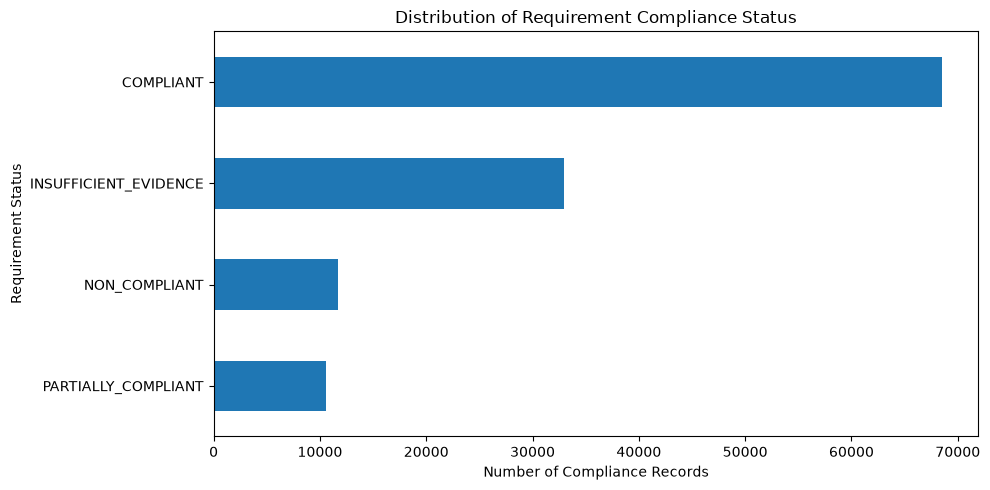

In [26]:
# ============================================================
# Requirement Status Distribution
# ============================================================

status_counts = compliance_results["requirement_status"].value_counts()

plt.figure(figsize=(10, 5))
status_counts.sort_values().plot(kind="barh")

plt.title("Distribution of Requirement Compliance Status")
plt.xlabel("Number of Compliance Records")
plt.ylabel("Requirement Status")
plt.tight_layout()
plt.show()

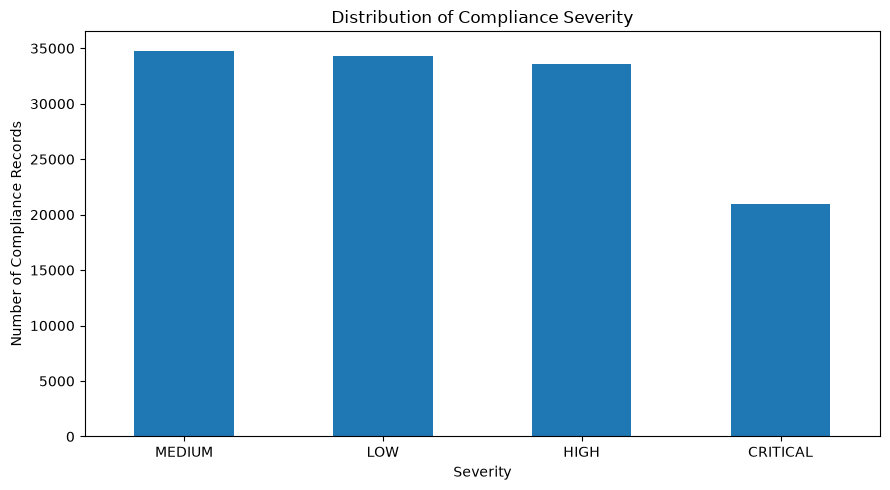

In [27]:
# ============================================================
# Compliance Severity Distribution
# ============================================================

severity_counts = compliance_results["severity"].value_counts()

plt.figure(figsize=(9, 5))
severity_counts.plot(kind="bar")

plt.title("Distribution of Compliance Severity")
plt.xlabel("Severity")
plt.ylabel("Number of Compliance Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

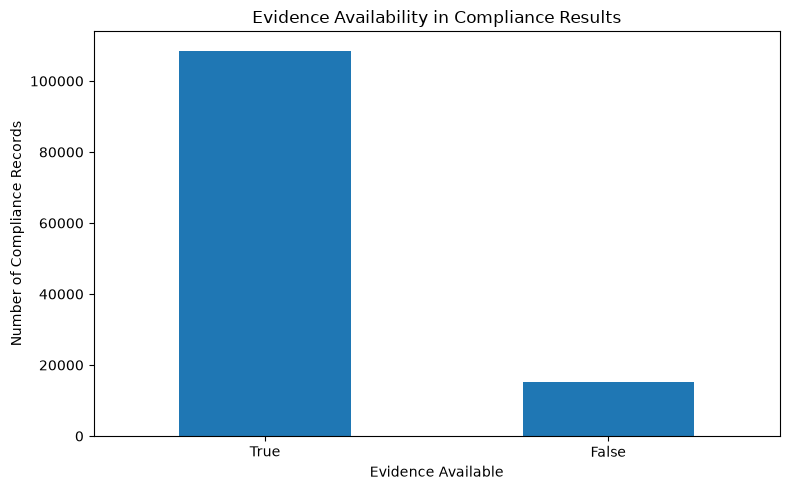

In [28]:
# ============================================================
# Evidence Availability Distribution
# ============================================================

evidence_counts = compliance_results["evidence_available"].value_counts()

plt.figure(figsize=(8, 5))
evidence_counts.plot(kind="bar")

plt.title("Evidence Availability in Compliance Results")
plt.xlabel("Evidence Available")
plt.ylabel("Number of Compliance Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [30]:
# ============================================================
# REQUIREMENT STATUS × SEVERITY ANALYSIS
# ============================================================

print("=" * 70)
print("REQUIREMENT STATUS × SEVERITY")
print("=" * 70)

status_severity = pd.crosstab(
    compliance_results["requirement_status"],
    compliance_results["severity"]
)

print(status_severity.to_string())

REQUIREMENT STATUS × SEVERITY
severity               CRITICAL   HIGH    LOW  MEDIUM
requirement_status                                   
COMPLIANT                 10261  19066  19302   19873
INSUFFICIENT_EVIDENCE      4240   9437   9606    9687
NON_COMPLIANT              4503   2366   2451    2351
PARTIALLY_COMPLIANT        1965   2747   2970    2878


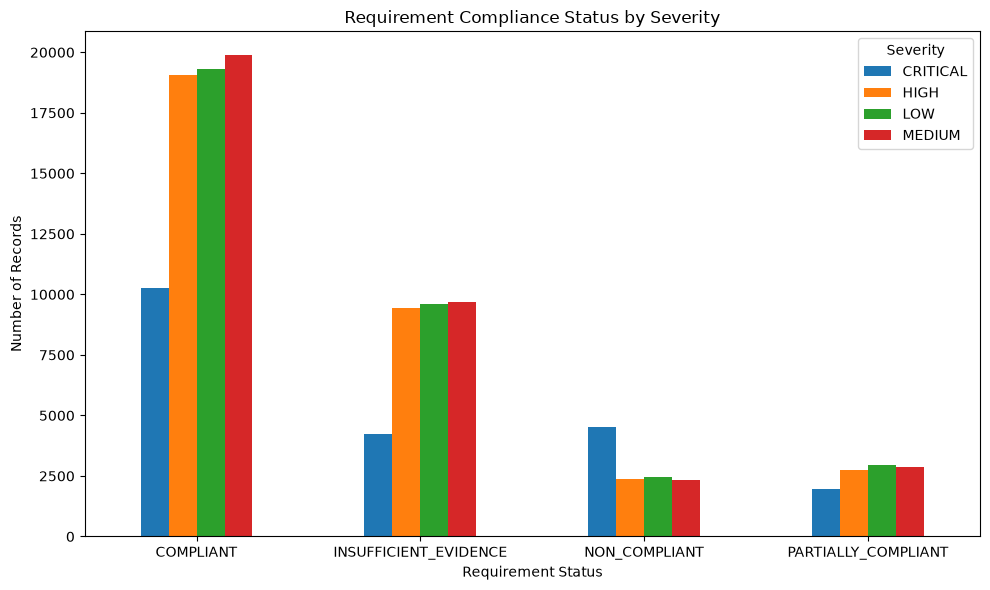

In [31]:
# ============================================================
# Requirement Status vs Severity
# ============================================================

status_severity.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Requirement Compliance Status by Severity")
plt.xlabel("Requirement Status")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.legend(title="Severity")
plt.tight_layout()
plt.show()

In [32]:
# ============================================================
# EVIDENCE AVAILABILITY × REQUIREMENT STATUS
# ============================================================

evidence_status = pd.crosstab(
    compliance_results["evidence_available"],
    compliance_results["requirement_status"]
)

print("=" * 70)
print("EVIDENCE AVAILABILITY × REQUIREMENT STATUS")
print("=" * 70)

print(evidence_status.to_string())

EVIDENCE AVAILABILITY × REQUIREMENT STATUS
requirement_status  COMPLIANT  INSUFFICIENT_EVIDENCE  NON_COMPLIANT  PARTIALLY_COMPLIANT
evidence_available                                                                      
False                       0                  15141              0                    0
True                    68502                  17829          11671                10560


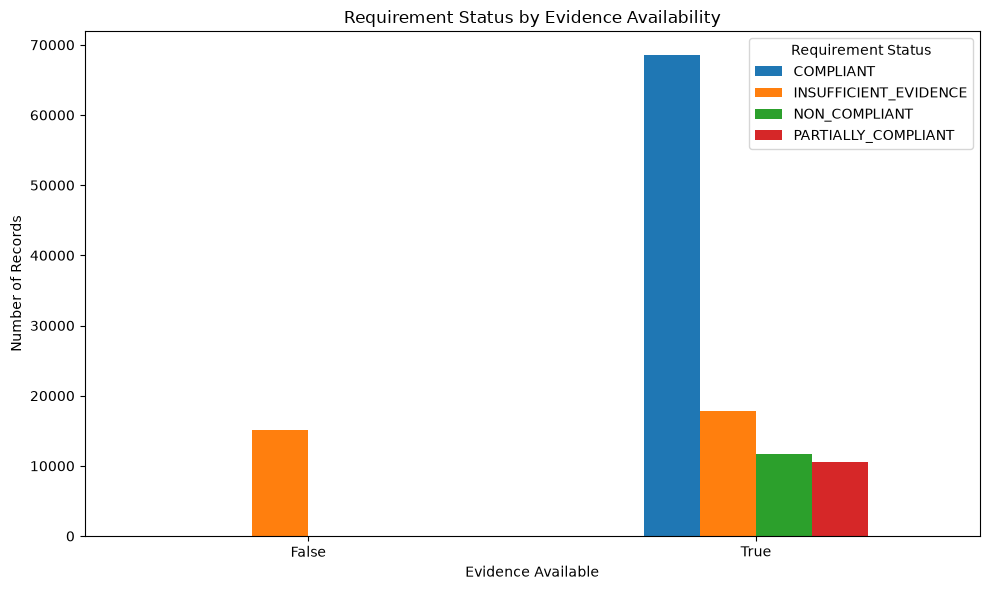

In [33]:
# ============================================================
# Evidence Availability vs Requirement Status
# ============================================================

evidence_status.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Requirement Status by Evidence Availability")
plt.xlabel("Evidence Available")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.legend(title="Requirement Status")
plt.tight_layout()
plt.show()

In [34]:
# ============================================================
# RISK DATASET ANALYSIS
# ============================================================

print("=" * 70)
print("RISK DATASET ANALYSIS")
print("=" * 70)

print("\nShape:")
print(risk_dataset.shape)

print("\nRisk Level Distribution:")
print(risk_dataset["risk_level"].value_counts())

print("\nRisk Level Percentage:")
print(
    risk_dataset["risk_level"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .to_string()
)

print("\nMissing Values:")
print(
    risk_dataset.isnull()
    .sum()
    .sort_values(ascending=False)
    .to_string()
)

RISK DATASET ANALYSIS

Shape:
(4748, 21)

Risk Level Distribution:
risk_level
LOW       1899
MEDIUM    1662
HIGH      1187
Name: count, dtype: int64

Risk Level Percentage:
risk_level
LOW       40.0
MEDIUM    35.0
HIGH      25.0

Missing Values:
tender_id                            0
bidder_id                            0
total_requirements                   0
mandatory_requirements               0
compliant_count                      0
partially_compliant_count            0
non_compliant_count                  0
insufficient_evidence_count          0
compliance_percentage                0
missing_document_count               0
expired_document_count               0
invalid_document_count               0
inconsistency_count                  0
evidence_confidence_average          0
mandatory_failure_count              0
financial_requirement_failure        0
experience_requirement_failure       0
registration_requirement_failure     0
authorization_requirement_failure    0
document_qual

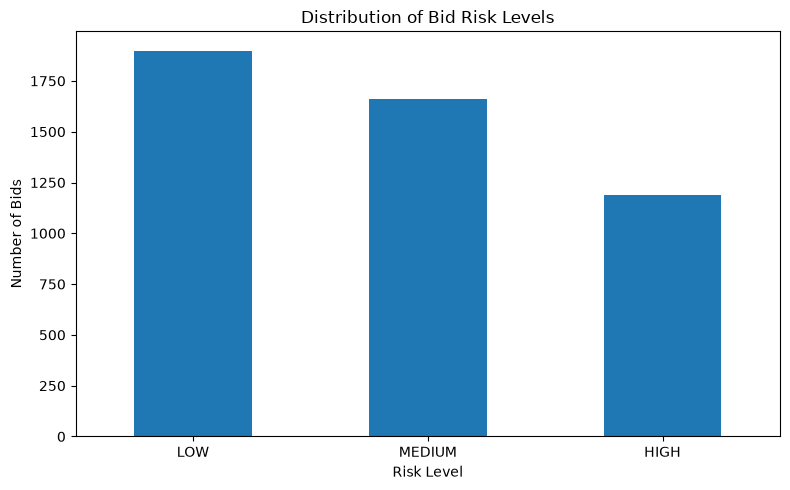

In [35]:
# ============================================================
# RISK LEVEL DISTRIBUTION
# ============================================================

risk_counts = risk_dataset["risk_level"].value_counts()

plt.figure(figsize=(8, 5))

risk_counts.plot(kind="bar")

plt.title("Distribution of Bid Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Number of Bids")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [36]:
# ============================================================
# RISK-WISE COMPLIANCE ANALYSIS
# ============================================================

print("=" * 70)
print("RISK-WISE COMPLIANCE PERCENTAGE")
print("=" * 70)

risk_compliance = (
    risk_dataset
    .groupby("risk_level")["compliance_percentage"]
    .agg(["count", "min", "max", "mean", "median"])
    .round(2)
)

print(risk_compliance.to_string())

RISK-WISE COMPLIANCE PERCENTAGE
            count    min    max   mean  median
risk_level                                    
HIGH         1187   0.00   68.0  14.85   13.33
LOW          1899  50.00  100.0  83.18   83.33
MEDIUM       1662  22.73   88.0  52.67   51.85


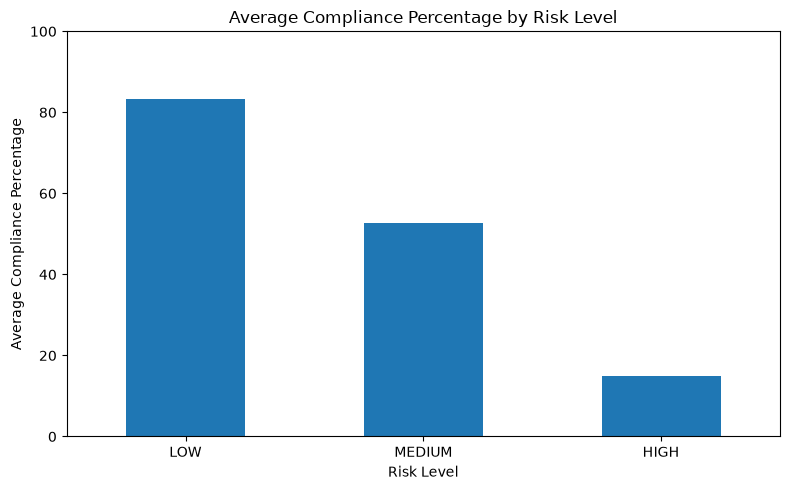

In [37]:
# ============================================================
# COMPLIANCE PERCENTAGE BY RISK LEVEL
# ============================================================

risk_order = ["LOW", "MEDIUM", "HIGH"]

risk_mean_compliance = (
    risk_dataset
    .groupby("risk_level")["compliance_percentage"]
    .mean()
    .reindex(risk_order)
)

plt.figure(figsize=(8, 5))

risk_mean_compliance.plot(kind="bar")

plt.title("Average Compliance Percentage by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Average Compliance Percentage")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [38]:
# ============================================================
# RISK-WISE FEATURE MEDIANS
# ============================================================

risk_features = [
    "compliance_percentage",
    "compliant_count",
    "partially_compliant_count",
    "non_compliant_count",
    "insufficient_evidence_count",
    "mandatory_failure_count",
    "missing_document_count",
    "expired_document_count",
    "invalid_document_count",
    "inconsistency_count",
    "evidence_confidence_average",
    "document_quality_score"
]

print("=" * 70)
print("RISK-WISE FEATURE MEDIANS")
print("=" * 70)

risk_feature_medians = (
    risk_dataset
    .groupby("risk_level")[risk_features]
    .median()
    .round(3)
)

print(risk_feature_medians.to_string())

RISK-WISE FEATURE MEDIANS
            compliance_percentage  compliant_count  partially_compliant_count  non_compliant_count  insufficient_evidence_count  mandatory_failure_count  missing_document_count  expired_document_count  invalid_document_count  inconsistency_count  evidence_confidence_average  document_quality_score
risk_level                                                                                                                                                                                                                                                                                                
HIGH                        13.33              3.0                        0.0                  3.0                         16.0                     14.0                     0.0                     0.0                     0.0                  0.0                        0.572                   0.833
LOW                         83.33             22.0                        1.0

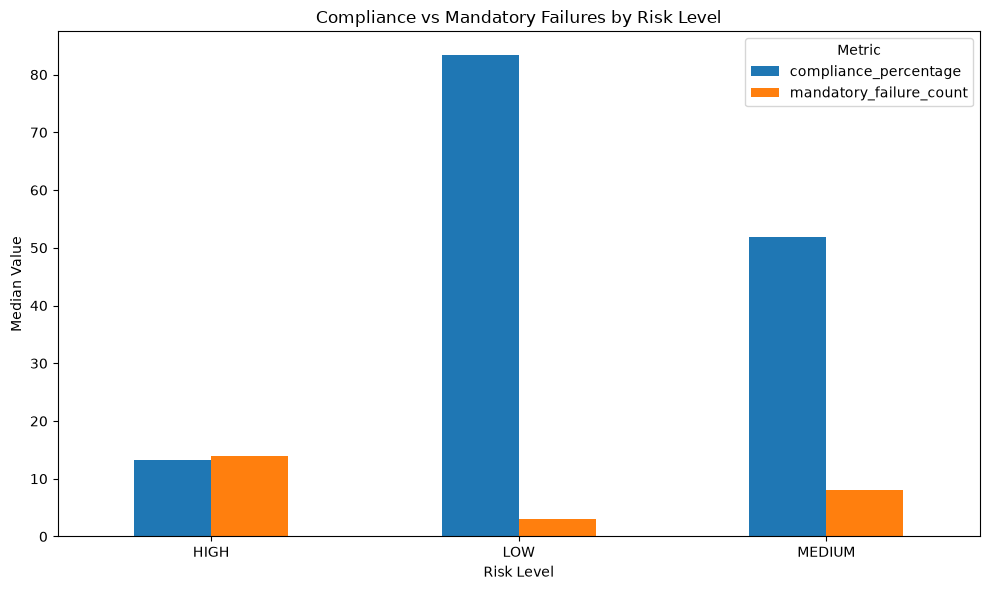

In [39]:
# ============================================================
# RISK-WISE COMPLIANCE AND MANDATORY FAILURE ANALYSIS
# ============================================================

risk_plot = risk_feature_medians[
    ["compliance_percentage", "mandatory_failure_count"]
]

risk_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Compliance vs Mandatory Failures by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Median Value")
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

EVIDENCE CONFIDENCE BY RISK LEVEL
risk_level
LOW       0.8354
MEDIUM    0.8265
HIGH      0.5718


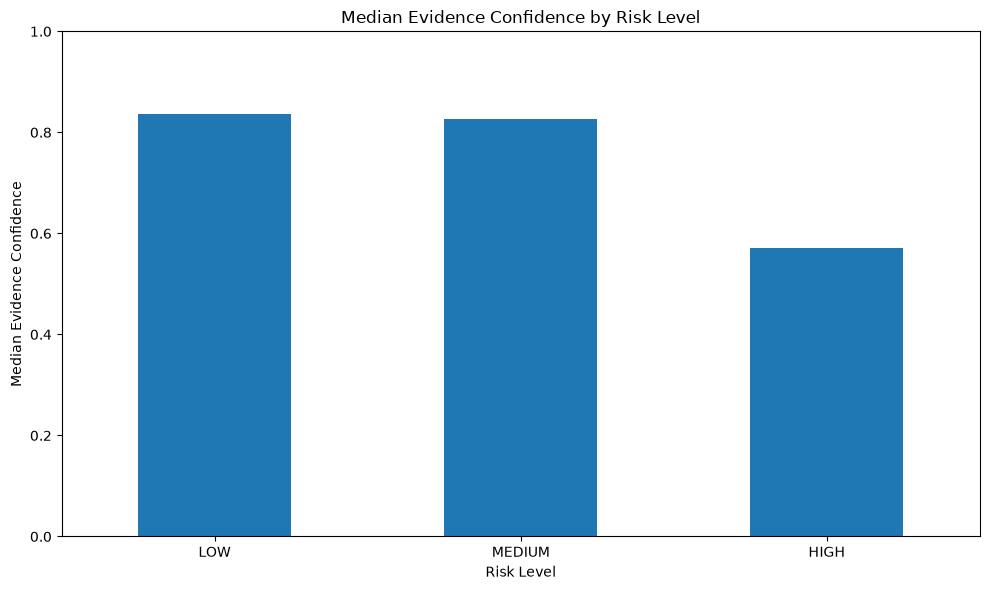

In [40]:
# ============================================================
# EVIDENCE CONFIDENCE BY RISK LEVEL
# ============================================================

risk_confidence = (
    risk_dataset
    .groupby("risk_level")["evidence_confidence_average"]
    .median()
    .sort_values(ascending=False)
)

print("=" * 70)
print("EVIDENCE CONFIDENCE BY RISK LEVEL")
print("=" * 70)
print(risk_confidence.to_string())

risk_confidence.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Median Evidence Confidence by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Median Evidence Confidence")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

COMPLIANCE RATE BY RISK LEVEL
             mean  median    min    max
risk_level                             
HIGH        14.85   13.33   0.00   68.0
LOW         83.18   83.33  50.00  100.0
MEDIUM      52.67   51.85  22.73   88.0


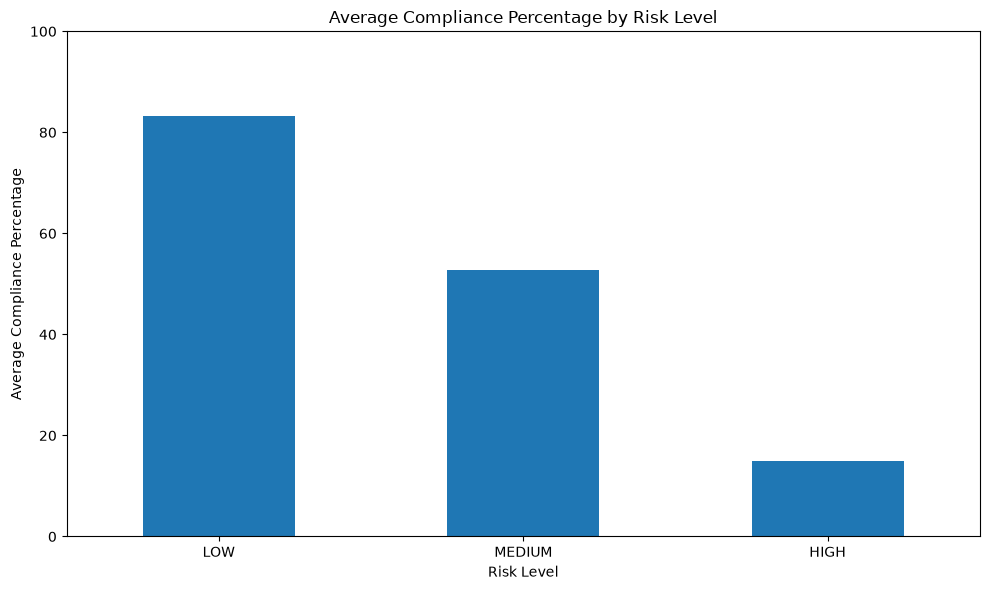

In [42]:
# ============================================================
# COMPLIANCE RATE BY RISK LEVEL
# ============================================================

compliance_by_risk = (
    risk_dataset
    .groupby("risk_level")["compliance_percentage"]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)

print("=" * 70)
print("COMPLIANCE RATE BY RISK LEVEL")
print("=" * 70)
print(compliance_by_risk.to_string())

compliance_by_risk["mean"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Compliance Percentage by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Average Compliance Percentage")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [43]:
# ================================================================
# RISK-WISE FAILURE ANALYSIS
# ================================================================

print("=" * 70)
print("RISK-WISE FAILURE ANALYSIS")
print("=" * 70)

failure_features = [
    "mandatory_failure_count",
    "missing_document_count",
    "expired_document_count",
    "invalid_document_count",
    "inconsistency_count"
]

risk_failures = (
    risk_dataset
    .groupby("risk_level")[failure_features]
    .median()
    .round(3)
)

print("\nMedian Failure Counts by Risk Level:\n")
print(risk_failures.to_string())

RISK-WISE FAILURE ANALYSIS

Median Failure Counts by Risk Level:

            mandatory_failure_count  missing_document_count  expired_document_count  invalid_document_count  inconsistency_count
risk_level                                                                                                                      
HIGH                           14.0                     0.0                     0.0                     0.0                  0.0
LOW                             3.0                     0.0                     0.0                     0.0                  0.0
MEDIUM                          8.0                     0.0                     0.0                     0.0                  0.0


RISK-WISE FAILURE DISTRIBUTION


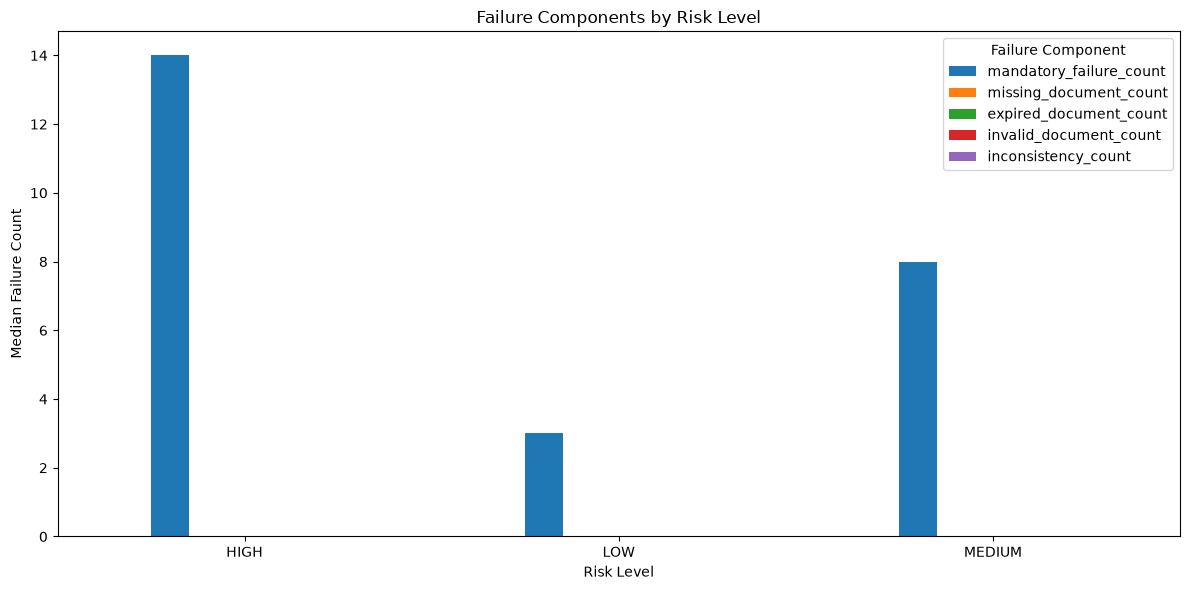

In [44]:
# ================================================================
# RISK-WISE FAILURE DISTRIBUTION
# ================================================================

print("=" * 70)
print("RISK-WISE FAILURE DISTRIBUTION")
print("=" * 70)

risk_failures.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Failure Components by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Median Failure Count")
plt.xticks(rotation=0)
plt.legend(title="Failure Component")
plt.tight_layout()
plt.show()

In [45]:
# ================================================================
# RISK LEVEL VS TOTAL FAILURE COUNT
# ================================================================

print("=" * 70)
print("RISK LEVEL VS TOTAL FAILURE COUNT")
print("=" * 70)

risk_total_failures = (
    risk_dataset
    .groupby("risk_level")[
        [
            "mandatory_failure_count",
            "missing_document_count",
            "expired_document_count",
            "invalid_document_count",
            "inconsistency_count"
        ]
    ]
    .sum()
)

risk_total_failures["total_failure_count"] = (
    risk_total_failures.sum(axis=1)
)

print("\nTotal Failure Count by Risk Level:\n")
print(risk_total_failures["total_failure_count"].sort_values(ascending=False).to_string())

RISK LEVEL VS TOTAL FAILURE COUNT

Total Failure Count by Risk Level:

risk_level
HIGH      19615
MEDIUM    14334
LOW        6316


In [46]:
# ================================================================
# AVERAGE FAILURE COUNT BY RISK LEVEL
# ================================================================

print("=" * 70)
print("AVERAGE FAILURE COUNT BY RISK LEVEL")
print("=" * 70)

risk_avg_failures = (
    risk_dataset
    .groupby("risk_level")[
        [
            "mandatory_failure_count",
            "missing_document_count",
            "expired_document_count",
            "invalid_document_count",
            "inconsistency_count"
        ]
    ]
    .mean()
    .round(2)
)

risk_avg_failures["average_total_failure_count"] = (
    risk_avg_failures.sum(axis=1).round(2)
)

print("\nAverage Failure Count by Risk Level:\n")
print(risk_avg_failures.to_string())

AVERAGE FAILURE COUNT BY RISK LEVEL

Average Failure Count by Risk Level:

            mandatory_failure_count  missing_document_count  expired_document_count  invalid_document_count  inconsistency_count  average_total_failure_count
risk_level                                                                                                                                                   
HIGH                          14.09                    0.50                    0.60                    0.62                 0.71                        16.52
LOW                            3.23                    0.09                    0.01                    0.01                 0.00                         3.34
MEDIUM                         8.09                    0.28                    0.10                    0.09                 0.07                         8.63


FAILURE COMPONENT COMPARISON BY RISK LEVEL

Average Failure Components:

            mandatory_failure_count  missing_document_count  expired_document_count  invalid_document_count  inconsistency_count  average_total_failure_count
risk_level                                                                                                                                                   
HIGH                          14.09                    0.50                    0.60                    0.62                 0.71                        16.52
LOW                            3.23                    0.09                    0.01                    0.01                 0.00                         3.34
MEDIUM                         8.09                    0.28                    0.10                    0.09                 0.07                         8.63


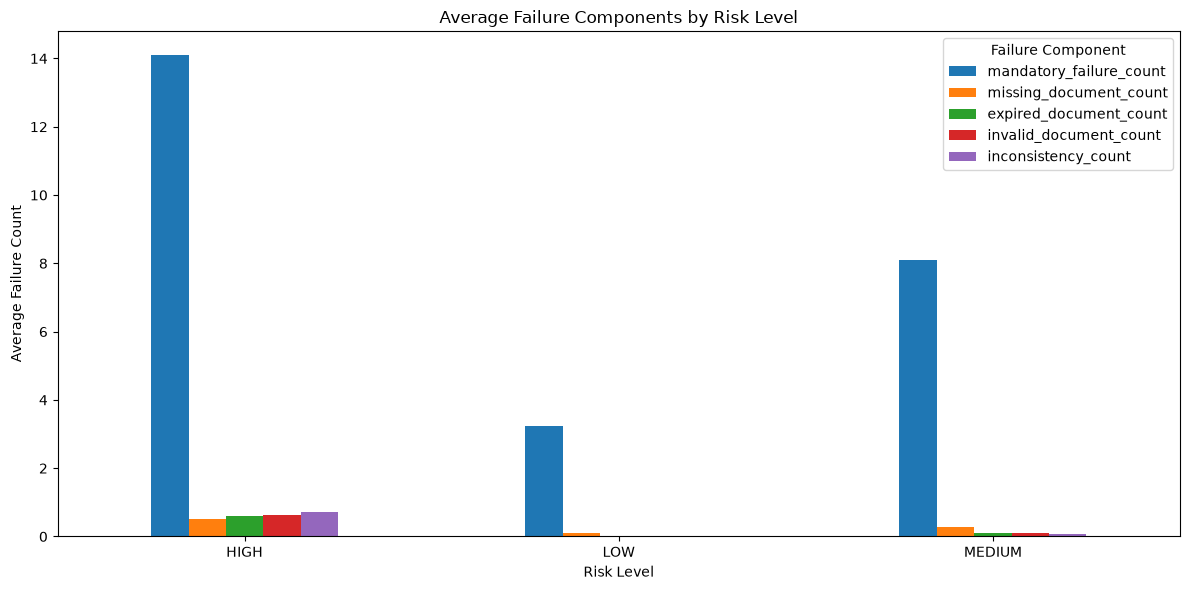

In [47]:
# ================================================================
# FAILURE COMPONENT COMPARISON BY RISK LEVEL
# ================================================================

print("=" * 70)
print("FAILURE COMPONENT COMPARISON BY RISK LEVEL")
print("=" * 70)

print("\nAverage Failure Components:\n")
print(risk_avg_failures.to_string())

risk_avg_failures[
    [
        "mandatory_failure_count",
        "missing_document_count",
        "expired_document_count",
        "invalid_document_count",
        "inconsistency_count"
    ]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Failure Components by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Average Failure Count")
plt.xticks(rotation=0)
plt.legend(title="Failure Component")
plt.tight_layout()
plt.show()

In [49]:
# ================================================================
# COMPLIANCE VS TOTAL FAILURES
# ================================================================

print("=" * 70)
print("COMPLIANCE VS TOTAL FAILURES")
print("=" * 70)

failure_columns = [
    "mandatory_failure_count",
    "missing_document_count",
    "expired_document_count",
    "invalid_document_count",
    "inconsistency_count"
]

# Calculate total failures for every record
risk_temp = risk_dataset.copy()

risk_temp["total_failure_count"] = (
    risk_temp[failure_columns].sum(axis=1)
)

# Aggregate by risk level
risk_compliance_failure = (
    risk_temp
    .groupby("risk_level")
    .agg(
        average_compliance_percentage=("compliance_percentage", "mean"),
        average_total_failure_count=("total_failure_count", "mean")
    )
    .round(2)
)

print("\nCompliance vs Average Total Failures:\n")
print(risk_compliance_failure.to_string())

COMPLIANCE VS TOTAL FAILURES

Compliance vs Average Total Failures:

            average_compliance_percentage  average_total_failure_count
risk_level                                                            
HIGH                                14.85                        16.52
LOW                                 83.18                         3.33
MEDIUM                              52.67                         8.62


In [50]:
# ================================================================
# OVERALL RISK LEVEL SUMMARY
# ================================================================

print("=" * 70)
print("OVERALL RISK LEVEL SUMMARY")
print("=" * 70)

risk_summary = (
    risk_dataset
    .groupby("risk_level")
    .agg(
        bid_count=("bidder_id", "count"),
        average_compliance=("compliance_percentage", "mean"),
        average_evidence_confidence=("evidence_confidence_average", "mean"),
        average_document_quality=("document_quality_score", "mean"),
        average_mandatory_failures=("mandatory_failure_count", "mean")
    )
    .round(2)
)

print("\nRisk Level Summary:\n")
print(risk_summary.to_string())

OVERALL RISK LEVEL SUMMARY

Risk Level Summary:

            bid_count  average_compliance  average_evidence_confidence  average_document_quality  average_mandatory_failures
risk_level                                                                                                                  
HIGH             1187               14.85                         0.54                      0.82                       14.09
LOW              1899               83.18                         0.83                      0.82                        3.23
MEDIUM           1662               52.67                         0.81                      0.82                        8.09


In [51]:
# ================================================================
# RISK LEVEL DISTRIBUTION PERCENTAGE
# ================================================================

print("=" * 70)
print("RISK LEVEL DISTRIBUTION PERCENTAGE")
print("=" * 70)

risk_distribution = (
    risk_dataset["risk_level"]
    .value_counts()
    .rename_axis("risk_level")
    .reset_index(name="bid_count")
)

risk_distribution["percentage"] = (
    risk_distribution["bid_count"]
    / risk_distribution["bid_count"].sum()
    * 100
).round(2)

print("\nRisk Level Distribution:\n")
print(risk_distribution.to_string(index=False))

RISK LEVEL DISTRIBUTION PERCENTAGE

Risk Level Distribution:

risk_level  bid_count  percentage
       LOW       1899        40.0
    MEDIUM       1662        35.0
      HIGH       1187        25.0


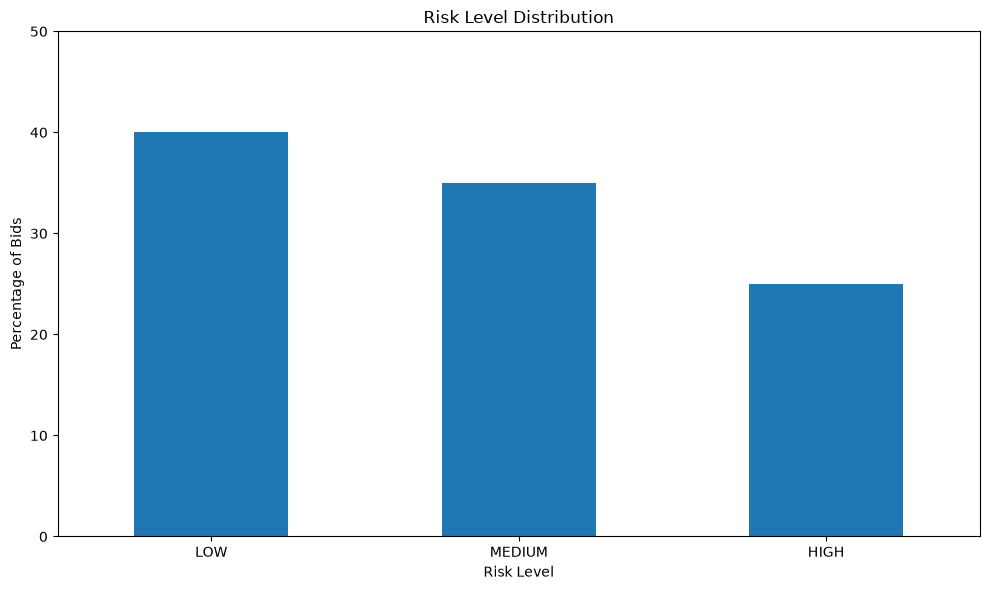

In [52]:
# ================================================================
# RISK LEVEL DISTRIBUTION CHART
# ================================================================

risk_distribution_plot = risk_distribution.set_index("risk_level")["percentage"]

risk_distribution_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Percentage of Bids")
plt.xticks(rotation=0)
plt.ylim(0, 50)
plt.tight_layout()
plt.show()

In [53]:
# ================================================================
# RISK LEVEL DISTRIBUTION SUMMARY
# ================================================================

print("=" * 70)
print("RISK LEVEL DISTRIBUTION SUMMARY")
print("=" * 70)

risk_distribution_summary = risk_distribution.copy()

print("\nRisk Level Distribution:")
print(risk_distribution_summary.to_string(index=False))

RISK LEVEL DISTRIBUTION SUMMARY

Risk Level Distribution:
risk_level  bid_count  percentage
       LOW       1899        40.0
    MEDIUM       1662        35.0
      HIGH       1187        25.0


In [54]:
# ================================================================
# RISK LEVEL VS COMPLIANCE AND EVIDENCE CONFIDENCE
# ================================================================

risk_quality = (
    risk_dataset
    .groupby("risk_level")
    .agg(
        average_compliance=("compliance_percentage", "mean"),
        average_evidence_confidence=("evidence_confidence_average", "mean")
    )
    .round(3)
)

print("=" * 70)
print("RISK LEVEL VS COMPLIANCE AND EVIDENCE CONFIDENCE")
print("=" * 70)

print("\nRisk Level Quality Analysis:\n")
print(risk_quality.to_string())

RISK LEVEL VS COMPLIANCE AND EVIDENCE CONFIDENCE

Risk Level Quality Analysis:

            average_compliance  average_evidence_confidence
risk_level                                                 
HIGH                    14.847                        0.544
LOW                     83.178                        0.833
MEDIUM                  52.671                        0.811


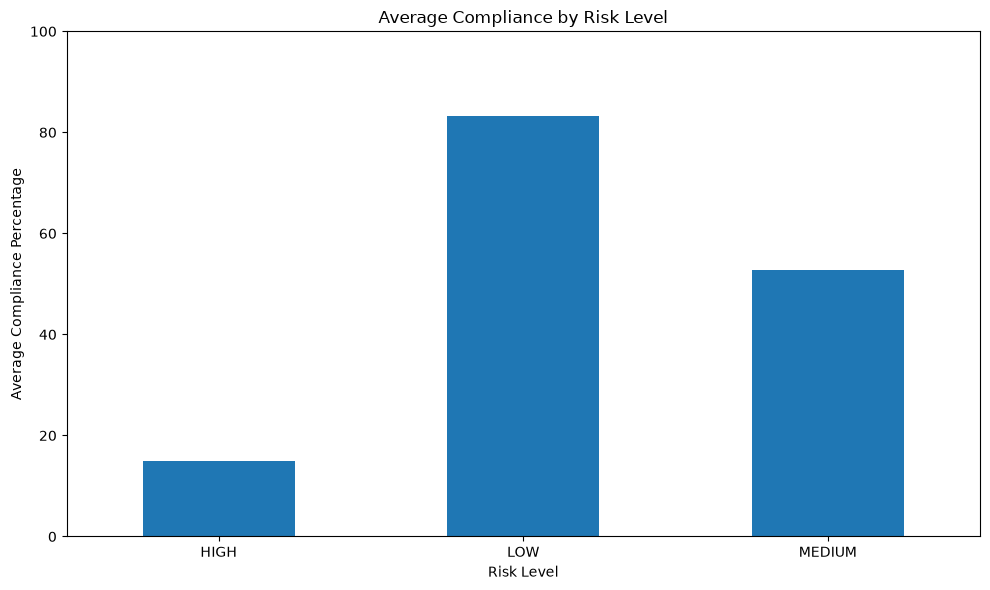

In [55]:
# ================================================================
# RISK LEVEL VS COMPLIANCE CHART
# ================================================================

risk_quality["average_compliance"].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Compliance by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Average Compliance Percentage")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

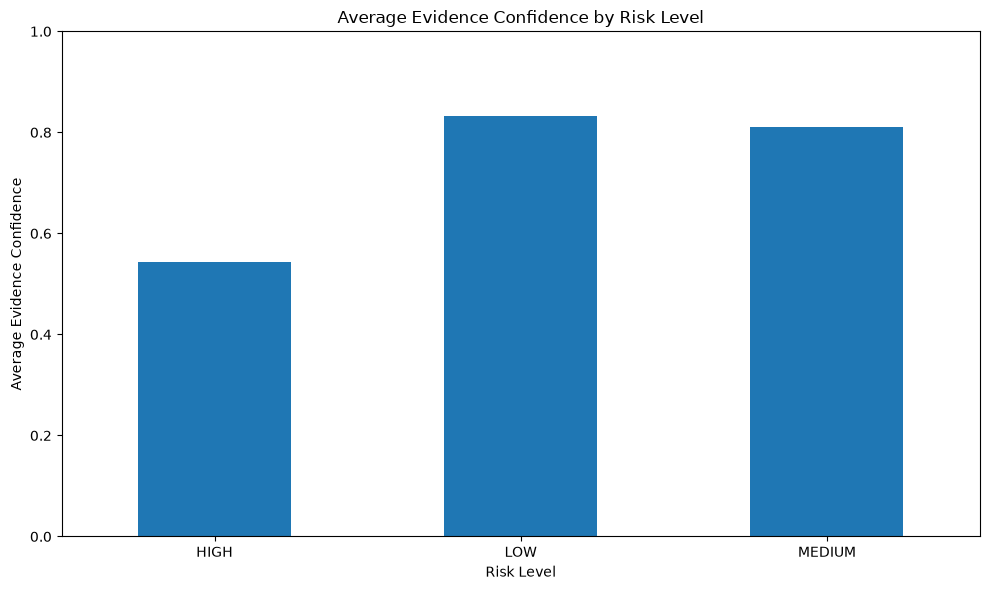

In [56]:
# ================================================================
# EVIDENCE CONFIDENCE BY RISK LEVEL
# ================================================================

risk_quality["average_evidence_confidence"].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Evidence Confidence by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Average Evidence Confidence")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [57]:
# ================================================================
# FINAL RISK LEVEL SUMMARY TABLE
# ================================================================

final_risk_summary = risk_summary.copy()

print("=" * 70)
print("FINAL RISK LEVEL SUMMARY")
print("=" * 70)

print("\nRisk Level Summary:\n")
print(final_risk_summary.to_string())

FINAL RISK LEVEL SUMMARY

Risk Level Summary:

            bid_count  average_compliance  average_evidence_confidence  average_document_quality  average_mandatory_failures
risk_level                                                                                                                  
HIGH             1187               14.85                         0.54                      0.82                       14.09
LOW              1899               83.18                         0.83                      0.82                        3.23
MEDIUM           1662               52.67                         0.81                      0.82                        8.09


In [58]:
# ================================================================
# OVERALL DATASET RISK SUMMARY
# ================================================================

overall_risk_summary = {
    "total_bids": len(risk_dataset),
    "low_risk_bids": (risk_dataset["risk_level"] == "LOW").sum(),
    "medium_risk_bids": (risk_dataset["risk_level"] == "MEDIUM").sum(),
    "high_risk_bids": (risk_dataset["risk_level"] == "HIGH").sum(),
    "average_compliance": round(
        risk_dataset["compliance_percentage"].mean(), 2
    ),
    "average_evidence_confidence": round(
        risk_dataset["evidence_confidence_average"].mean(), 3
    ),
    "average_document_quality": round(
        risk_dataset["document_quality_score"].mean(), 3
    ),
    "average_mandatory_failures": round(
        risk_dataset["mandatory_failure_count"].mean(), 2
    )
}

print("=" * 70)
print("OVERALL DATASET RISK SUMMARY")
print("=" * 70)

for key, value in overall_risk_summary.items():
    print(f"{key}: {value}")

OVERALL DATASET RISK SUMMARY
total_bids: 4748
low_risk_bids: 1899
medium_risk_bids: 1662
high_risk_bids: 1187
average_compliance: 55.42
average_evidence_confidence: 0.753
average_document_quality: 0.822
average_mandatory_failures: 7.64


In [59]:
# ================================================================
# KEY EDA FINDINGS
# ================================================================

print("=" * 70)
print("KEY EDA FINDINGS")
print("=" * 70)

highest_compliance_risk = risk_summary["average_compliance"].idxmax()
lowest_compliance_risk = risk_summary["average_compliance"].idxmin()

highest_failure_risk = risk_summary["average_mandatory_failures"].idxmax()
highest_confidence_risk = risk_summary["average_evidence_confidence"].idxmax()
lowest_confidence_risk = risk_summary["average_evidence_confidence"].idxmin()

print(f"\n1. Highest average compliance: {highest_compliance_risk}")
print(
    f"   Compliance: "
    f"{risk_summary.loc[highest_compliance_risk, 'average_compliance']:.2f}%"
)

print(f"\n2. Lowest average compliance: {lowest_compliance_risk}")
print(
    f"   Compliance: "
    f"{risk_summary.loc[lowest_compliance_risk, 'average_compliance']:.2f}%"
)

print(f"\n3. Highest average mandatory failures: {highest_failure_risk}")
print(
    f"   Mandatory failures: "
    f"{risk_summary.loc[highest_failure_risk, 'average_mandatory_failures']:.2f}"
)

print(f"\n4. Highest evidence confidence: {highest_confidence_risk}")
print(
    f"   Evidence confidence: "
    f"{risk_summary.loc[highest_confidence_risk, 'average_evidence_confidence']:.3f}"
)

print(f"\n5. Lowest evidence confidence: {lowest_confidence_risk}")
print(
    f"   Evidence confidence: "
    f"{risk_summary.loc[lowest_confidence_risk, 'average_evidence_confidence']:.3f}"
)

print("\n6. Overall average compliance:")
print(f"   {overall_risk_summary['average_compliance']:.2f}%")

print("\n7. Overall average evidence confidence:")
print(f"   {overall_risk_summary['average_evidence_confidence']:.3f}")

print("\n8. Overall average mandatory failures:")
print(f"   {overall_risk_summary['average_mandatory_failures']:.2f}")

KEY EDA FINDINGS

1. Highest average compliance: LOW
   Compliance: 83.18%

2. Lowest average compliance: HIGH
   Compliance: 14.85%

3. Highest average mandatory failures: HIGH
   Mandatory failures: 14.09

4. Highest evidence confidence: LOW
   Evidence confidence: 0.830

5. Lowest evidence confidence: HIGH
   Evidence confidence: 0.540

6. Overall average compliance:
   55.42%

7. Overall average evidence confidence:
   0.753

8. Overall average mandatory failures:
   7.64


RISK LEVEL DISTRIBUTION - FINAL VISUALIZATION


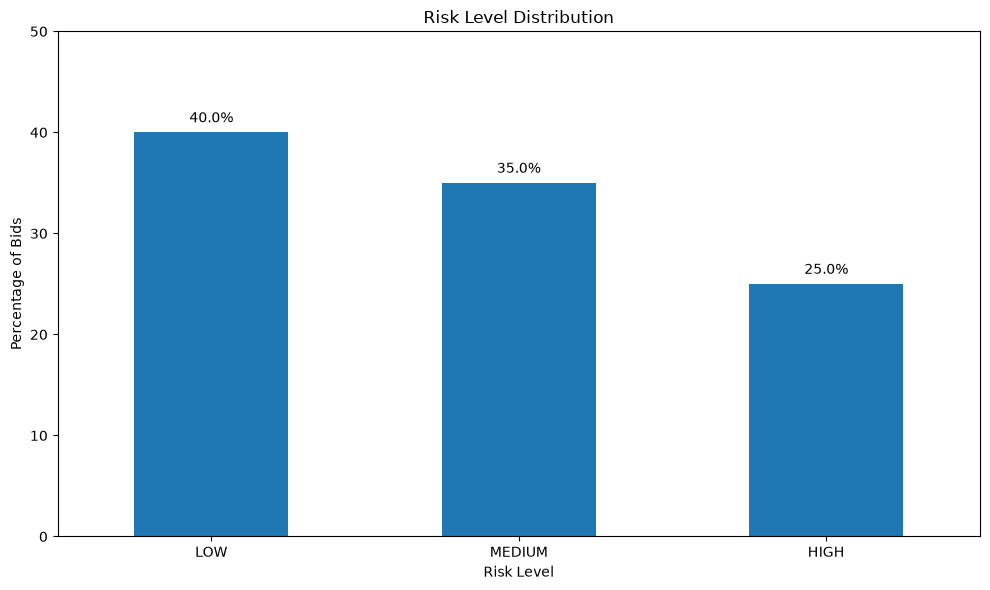

In [60]:
# ================================================================
# RISK LEVEL DISTRIBUTION - FINAL VISUALIZATION
# ================================================================

print("=" * 70)
print("RISK LEVEL DISTRIBUTION - FINAL VISUALIZATION")
print("=" * 70)

distribution_plot = risk_distribution.set_index("risk_level")["percentage"]

ax = distribution_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Percentage of Bids")
plt.xticks(rotation=0)
plt.ylim(0, 50)

for i, value in enumerate(distribution_plot):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

COMPLIANCE VS EVIDENCE CONFIDENCE BY RISK LEVEL


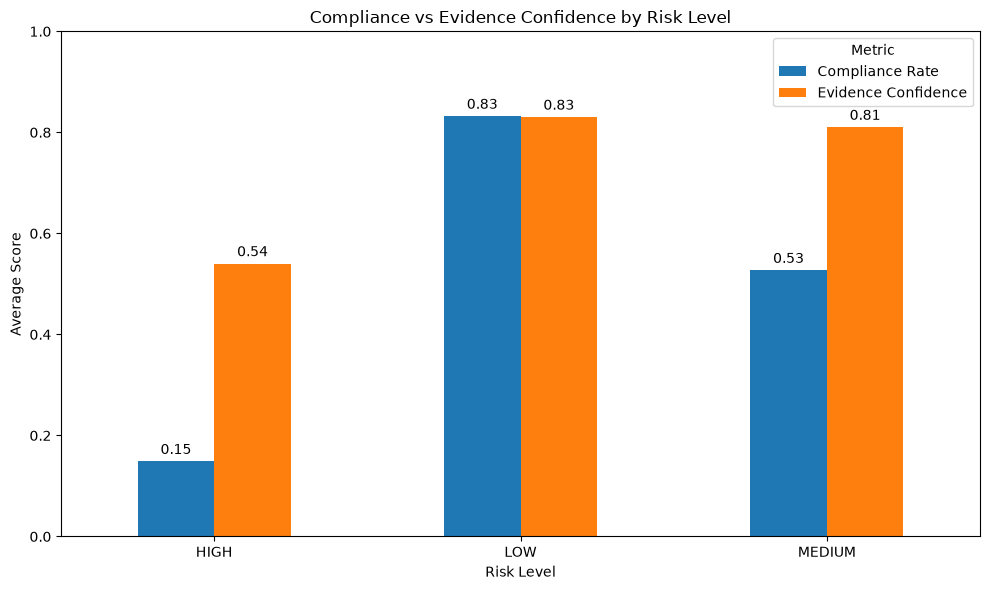

In [61]:
# ================================================================
# COMPLIANCE VS EVIDENCE CONFIDENCE BY RISK LEVEL
# ================================================================

print("=" * 70)
print("COMPLIANCE VS EVIDENCE CONFIDENCE BY RISK LEVEL")
print("=" * 70)

quality_plot = risk_summary[
    [
        "average_compliance",
        "average_evidence_confidence"
    ]
].copy()

# Convert compliance percentage to 0–1 scale
quality_plot["average_compliance"] = (
    quality_plot["average_compliance"] / 100
)

ax = quality_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Compliance vs Evidence Confidence by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

plt.legend(
    ["Compliance Rate", "Evidence Confidence"],
    title="Metric"
)

plt.tight_layout()
plt.show()

In [62]:
# ================================================================
# AVERAGE FAILURE COUNT BY RISK LEVEL
# ================================================================

print("=" * 70)
print("AVERAGE FAILURE COUNT BY RISK LEVEL")
print("=" * 70)

failure_columns = [
    "mandatory_failure_count",
    "missing_document_count",
    "expired_document_count",
    "invalid_document_count",
    "inconsistency_count"
]

average_failures = (
    risk_dataset
    .groupby("risk_level")[failure_columns]
    .mean()
    .round(2)
)

average_failures["average_total_failure_count"] = (
    average_failures.sum(axis=1)
).round(2)

print("\nAverage Failure Count by Risk Level:\n")
print(average_failures.to_string())

AVERAGE FAILURE COUNT BY RISK LEVEL

Average Failure Count by Risk Level:

            mandatory_failure_count  missing_document_count  expired_document_count  invalid_document_count  inconsistency_count  average_total_failure_count
risk_level                                                                                                                                                   
HIGH                          14.09                    0.50                    0.60                    0.62                 0.71                        16.52
LOW                            3.23                    0.09                    0.01                    0.01                 0.00                         3.34
MEDIUM                         8.09                    0.28                    0.10                    0.09                 0.07                         8.63


AVERAGE FAILURE COMPONENTS BY RISK LEVEL


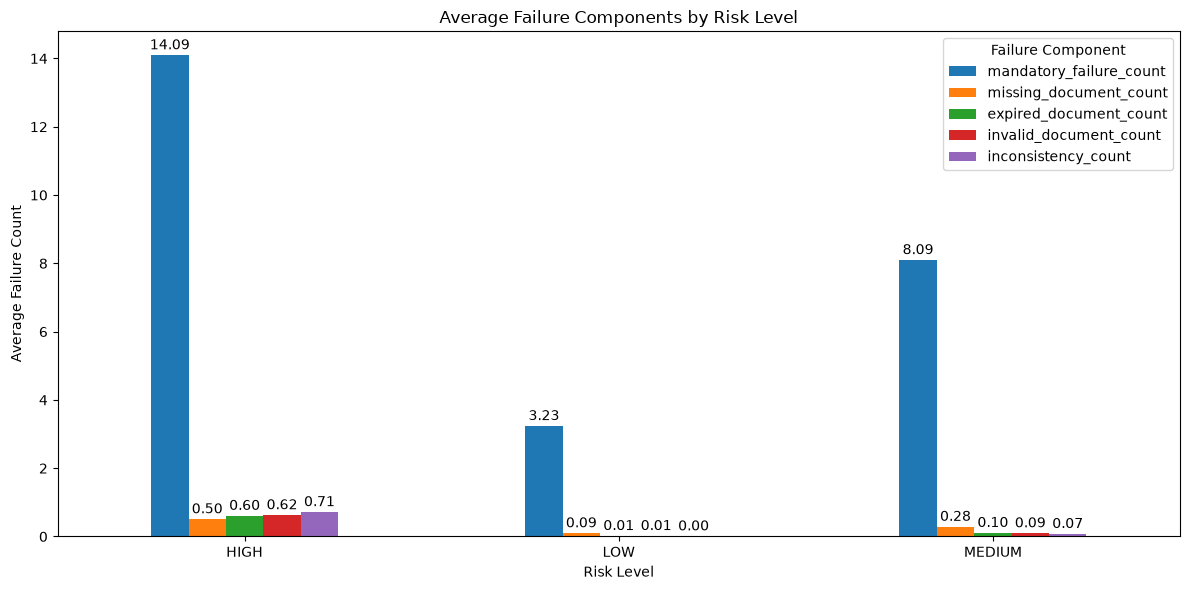

In [63]:
# ================================================================
# AVERAGE FAILURE COMPONENTS BY RISK LEVEL
# ================================================================

print("=" * 70)
print("AVERAGE FAILURE COMPONENTS BY RISK LEVEL")
print("=" * 70)

failure_plot = average_failures[
    [
        "mandatory_failure_count",
        "missing_document_count",
        "expired_document_count",
        "invalid_document_count",
        "inconsistency_count"
    ]
]

ax = failure_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Failure Components by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Average Failure Count")
plt.xticks(rotation=0)
plt.legend(title="Failure Component")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=2
    )

plt.tight_layout()
plt.show()

In [64]:
# ================================================================
# COMPLIANCE VS AVERAGE TOTAL FAILURES
# ================================================================

print("=" * 70)
print("COMPLIANCE VS AVERAGE TOTAL FAILURES")
print("=" * 70)

compliance_failure = risk_summary[
    [
        "average_compliance",
        "average_mandatory_failures"
    ]
].copy()

# Add total average failure count from previous analysis
compliance_failure["average_total_failures"] = (
    average_failures["average_total_failure_count"]
)

print("\nCompliance vs Average Total Failures:\n")
print(compliance_failure.to_string())

COMPLIANCE VS AVERAGE TOTAL FAILURES

Compliance vs Average Total Failures:

            average_compliance  average_mandatory_failures  average_total_failures
risk_level                                                                        
HIGH                     14.85                       14.09                   16.52
LOW                      83.18                        3.23                    3.34
MEDIUM                   52.67                        8.09                    8.63


COMPLIANCE VS AVERAGE TOTAL FAILURES - VISUALIZATION


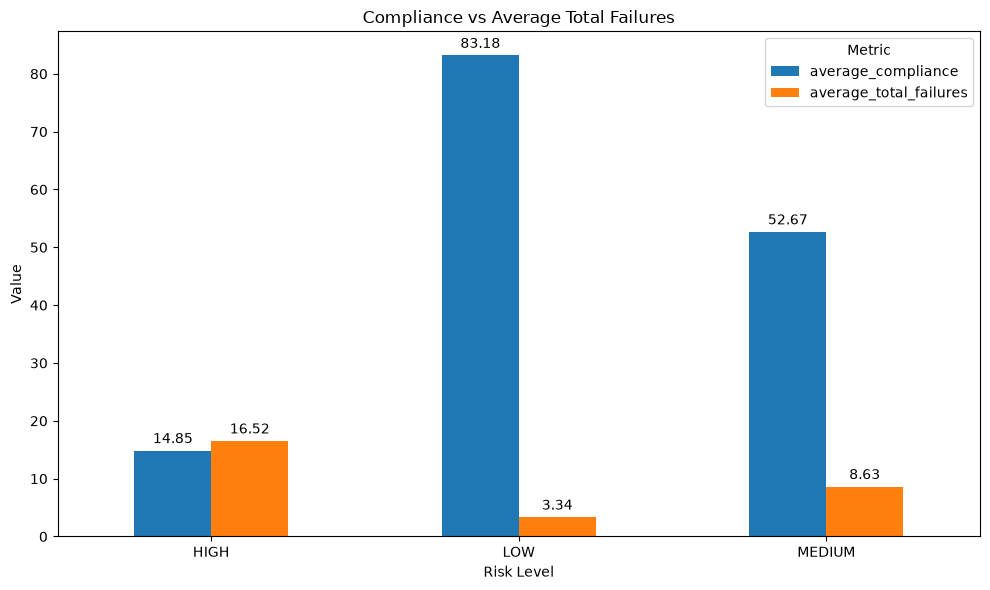

In [65]:
# ================================================================
# COMPLIANCE VS AVERAGE TOTAL FAILURES - VISUALIZATION
# ================================================================

print("=" * 70)
print("COMPLIANCE VS AVERAGE TOTAL FAILURES - VISUALIZATION")
print("=" * 70)

plot_data = compliance_failure[
    [
        "average_compliance",
        "average_total_failures"
    ]
].copy()

ax = plot_data.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Compliance vs Average Total Failures")
plt.xlabel("Risk Level")
plt.ylabel("Value")
plt.xticks(rotation=0)
plt.legend(title="Metric")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

plt.tight_layout()
plt.show()

In [66]:
# ================================================================
# FINAL EDA CONCLUSIONS
# ================================================================

print("=" * 70)
print("FINAL EDA CONCLUSIONS - BIDGUARD AI")
print("=" * 70)

print("\n1. DATASET OVERVIEW")
print("-" * 70)
print(f"Total bids analysed: {len(risk_dataset):,}")

print("\n2. RISK LEVEL DISTRIBUTION")
print("-" * 70)
for level in ["LOW", "MEDIUM", "HIGH"]:
    count = int(risk_dataset["risk_level"].value_counts().get(level, 0))
    percentage = (count / len(risk_dataset)) * 100
    print(f"{level:<10}: {count:>5,} bids ({percentage:.2f}%)")

print("\n3. COMPLIANCE ANALYSIS")
print("-" * 70)
print(
    f"Overall average compliance: "
    f"{risk_dataset['compliance_percentage'].mean():.2f}%"
)

compliance_by_risk = (
    risk_dataset.groupby("risk_level")["compliance_percentage"]
    .mean()
    .sort_values(ascending=False)
)

for level, value in compliance_by_risk.items():
    print(f"{level:<10}: {value:.2f}% average compliance")

print("\n4. FAILURE ANALYSIS")
print("-" * 70)
print(
    f"Overall average mandatory failures: "
    f"{risk_dataset['mandatory_failure_count'].mean():.2f}"
)

failure_by_risk = (
    risk_dataset.groupby("risk_level")["mandatory_failure_count"]
    .mean()
    .sort_values(ascending=False)
)

for level, value in failure_by_risk.items():
    print(f"{level:<10}: {value:.2f} average mandatory failures")

print("\n5. EVIDENCE QUALITY")
print("-" * 70)
print(
    f"Overall average evidence confidence: "
    f"{risk_dataset['evidence_confidence_average'].mean():.3f}"
)

evidence_by_risk = (
    risk_dataset.groupby("risk_level")["evidence_confidence_average"]
    .mean()
    .sort_values(ascending=False)
)

for level, value in evidence_by_risk.items():
    print(f"{level:<10}: {value:.3f} average evidence confidence")

print("\n6. KEY OBSERVATIONS")
print("-" * 70)

highest_compliance = compliance_by_risk.idxmax()
lowest_compliance = compliance_by_risk.idxmin()
highest_failures = failure_by_risk.idxmax()
lowest_evidence = evidence_by_risk.idxmin()

print(
    f"• {highest_compliance} risk bids have the highest average compliance "
    f"({compliance_by_risk.max():.2f}%)."
)

print(
    f"• {lowest_compliance} risk bids have the lowest average compliance "
    f"({compliance_by_risk.min():.2f}%)."
)

print(
    f"• {highest_failures} risk bids have the highest average mandatory "
    f"failures ({failure_by_risk.max():.2f})."
)

print(
    f"• {lowest_evidence} risk bids have the lowest evidence confidence "
    f"({evidence_by_risk.min():.3f})."
)

print("\n7. EDA CONCLUSION")
print("-" * 70)
print(
    "The EDA shows a clear relationship between bid risk, compliance, "
    "mandatory failures, and evidence confidence."
)

print(
    "Higher-risk bids exhibit substantially lower compliance and higher "
    "mandatory failure counts, while lower-risk bids show stronger "
    "compliance and evidence confidence."
)

print(
    "These patterns indicate that the dataset contains meaningful "
    "signals for developing an AI-based bid compliance and risk "
    "assessment model."
)

print("\n" + "=" * 70)
print("EDA COMPLETED SUCCESSFULLY")
print("=" * 70)

FINAL EDA CONCLUSIONS - BIDGUARD AI

1. DATASET OVERVIEW
----------------------------------------------------------------------
Total bids analysed: 4,748

2. RISK LEVEL DISTRIBUTION
----------------------------------------------------------------------
LOW       : 1,899 bids (40.00%)
MEDIUM    : 1,662 bids (35.00%)
HIGH      : 1,187 bids (25.00%)

3. COMPLIANCE ANALYSIS
----------------------------------------------------------------------
Overall average compliance: 55.42%
LOW       : 83.18% average compliance
MEDIUM    : 52.67% average compliance
HIGH      : 14.85% average compliance

4. FAILURE ANALYSIS
----------------------------------------------------------------------
Overall average mandatory failures: 7.64
HIGH      : 14.09 average mandatory failures
MEDIUM    : 8.09 average mandatory failures
LOW       : 3.23 average mandatory failures

5. EVIDENCE QUALITY
----------------------------------------------------------------------
Overall average evidence confidence: 0.753
LOW  

# BidGuard AI — EDA Conclusions

## Dataset Overview

- Total bids analysed: 4,748
- LOW risk: 1,899 (40%)
- MEDIUM risk: 1,662 (35%)
- HIGH risk: 1,187 (25%)

## Compliance

- Overall average compliance: 55.42%
- LOW: 83.18%
- MEDIUM: 52.67%
- HIGH: 14.85%

## Failure Analysis

- Overall average mandatory failures: 7.64
- LOW: 3.23
- MEDIUM: 8.09
- HIGH: 14.09

## Evidence Confidence

- Overall average evidence confidence: 0.753
- LOW: 0.833
- MEDIUM: 0.811
- HIGH: 0.544

## Key Findings

1. LOW-risk bids demonstrate the highest compliance.
2. HIGH-risk bids demonstrate the lowest compliance.
3. HIGH-risk bids have substantially more mandatory failures.
4. HIGH-risk bids have the lowest evidence confidence.
5. Risk level shows meaningful relationships with compliance,
   failure counts, and evidence quality.

## Conclusion

The EDA indicates that the dataset contains meaningful signals
for AI-based bid compliance verification and risk assessment.